# EXEMPLO 2: RRF vs Normalization — Ollama BGE-M3 (client-side)

**Objetivo**: Comparar duas estratégias de **rank fusion** (RRF × Min-Max) em busca híbrida no OpenSearch 3.x, usando **embeddings BGE-M3 via Ollama** (`/api/embeddings`, dim=1024) gerados no cliente.

Este notebook demonstra:
- Embedding **client-side** via Ollama (`ollama_embed`)
- Pipeline RRF (Reciprocal Rank Fusion) — sintaxe oficial `score-ranker-processor` (OpenSearch 2.19+)
- Pipeline com Min-Max Normalization (`normalization-processor`)
- Comparação lado a lado de scores e rankings
- Tabela de decisão de quando usar cada técnica

**Referência (RRF)**: BOGAN, R. et al. *Introducing reciprocal rank fusion for hybrid search*. OpenSearch Blog, 12 fev. 2025. <https://opensearch.org/blog/introducing-reciprocal-rank-fusion-hybrid-search/>

> **Pré-requisito**: Ollama rodando com `bge-m3` carregado (`ollama pull bge-m3`).

## Setup

In [5]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                       'opensearch-py', 'pandas', 'matplotlib', 'requests'])

import os, requests
from opensearchpy import OpenSearch
from typing import List, Dict
import pandas as pd
import matplotlib.pyplot as plt

# Conexão OpenSearch
client = OpenSearch(
    hosts=[{'host': 'localhost', 'port': 9200}],
    http_auth=('admin', 'admin'),
    use_ssl=False, verify_certs=False,
)

# Ollama (embeddings BGE-M3)
OLLAMA_BASE_URL    = os.getenv('OLLAMA_BASE_URL', 'http://localhost:11434')
OLLAMA_EMBED_MODEL = os.getenv('OLLAMA_EMBED_MODEL', 'bge-m3')
EMBED_DIM = 1024  # BGE-M3

print(f"✓ OpenSearch {client.info()['version']['number']}")
print(f"✓ Ollama embeddings: {OLLAMA_BASE_URL} ({OLLAMA_EMBED_MODEL}, dim={EMBED_DIM})")

✓ OpenSearch 3.0.0
✓ Ollama embeddings: http://localhost:11434 (bge-m3, dim=1024)


## Função de Embedding (Ollama BGE-M3)

Todas as queries e documentos passarão por esta função — embedding **real, multilíngue, semântico** — em vez de hash MD5 sintético.

In [6]:
def ollama_embed(text: str,
                 model: str = OLLAMA_EMBED_MODEL,
                 base_url: str = OLLAMA_BASE_URL) -> List[float]:
    """Gera embedding BGE-M3 via Ollama HTTP. Fallback: vetor zero (1024d)."""
    try:
        r = requests.post(
            f'{base_url}/api/embeddings',
            json={'model': model, 'prompt': text},
            timeout=60,
        )
        r.raise_for_status()
        emb = r.json().get('embedding', [])
        if len(emb) != EMBED_DIM:
            raise ValueError(f'dim inesperada: {len(emb)}')
        return emb
    except Exception as e:
        print(f'⚠️ Ollama indisponível ({e}). Vetor zero.')
        return [0.0] * EMBED_DIM

# Smoke test
_v = ollama_embed('teste de embedding')
print(f'✓ Dim do embedding gerado pelo Ollama: {len(_v)}')

✓ Dim do embedding gerado pelo Ollama: 1024


## Criar Índice (dim=1024 para BGE-M3)

In [7]:
index_name = 'indice_comparacao_fusion_bge_m3'

try:
    client.indices.delete(index=index_name)
except Exception:
    pass

mapping = {
    'settings': {'number_of_shards': 1, 'index': {'knn': True}},
    'mappings': {
        'properties': {
            'titulo':   {'type': 'text', 'analyzer': 'portuguese'},
            'conteudo': {'type': 'text', 'analyzer': 'portuguese'},
            'embedding': {
                'type': 'knn_vector',
                'dimension': EMBED_DIM,
                'method': {'name': 'hnsw', 'space_type': 'cosinesimil', 'engine': 'faiss'}
            }
        }
    }
}
client.indices.create(index=index_name, body=mapping)
print(f'✓ Índice criado: {index_name} (dim={EMBED_DIM})')

✓ Índice criado: indice_comparacao_fusion_bge_m3 (dim=1024)


## Indexar Documentos com Embeddings Ollama

In [8]:
docs = [
    {'id': '1', 'titulo': 'Acesso à Informação Pública',
     'conteudo': 'Lei de Acesso à Informação garante direito irrestrito a informações públicas'},
    {'id': '2', 'titulo': 'Proteção de Dados Pessoais',
     'conteudo': 'LGPD protege dados pessoais e privacidade dos cidadãos brasileiros'},
    {'id': '3', 'titulo': 'Direitos Fundamentais',
     'conteudo': 'Constituição Federal garante vida, liberdade, igualdade, segurança e propriedade'},
    {'id': '4', 'titulo': 'Responsabilidade Civil do Estado',
     'conteudo': 'Estado responde por danos causados por seus agentes públicos'},
    {'id': '5', 'titulo': 'Segurança Pública',
     'conteudo': 'Segurança pública é direito e responsabilidade de todos, respeitando direitos fundamentais'},
]

for d in docs:
    d['embedding'] = ollama_embed(d['conteudo'])
    client.index(index=index_name, id=d['id'],
                 body={'titulo': d['titulo'], 'conteudo': d['conteudo'], 'embedding': d['embedding']})

client.indices.refresh(index=index_name)
print(f"✓ {len(docs)} documentos indexados (embeddings BGE-M3 via Ollama)")

✓ 5 documentos indexados (embeddings BGE-M3 via Ollama)


## Criar Pipelines: RRF (`score-ranker-processor`) e Min-Max (`normalization-processor`)

**RRF** (OpenSearch 2.19+) usa o **novo processor `score-ranker-processor`** com `technique: rrf` e `rank_constant` (default 60). Não recebe `weights` (suporte previsto no roadmap).

**Min-Max** continua no `normalization-processor`, aceitando `weights` na combinação.

In [9]:
# Limpar pipelines antigos
for name in ['rrf_pipeline_exemplo2', 'normalization_pipeline_exemplo2']:
    try:
        client.transport.perform_request('DELETE', f'/_search/pipeline/{name}')
    except Exception:
        pass

# ---------------------------------------------------------------------------
# Pipeline 1: RRF — Reciprocal Rank Fusion (sintaxe oficial OpenSearch 2.19+)
# Ref.: https://opensearch.org/blog/introducing-reciprocal-rank-fusion-hybrid-search/
# ---------------------------------------------------------------------------
rrf_pipeline = {
    'description': 'Post processor for hybrid RRF search (BM25 + Ollama BGE-M3)',
    'phase_results_processors': [
        {
            'score-ranker-processor': {
                'combination': {
                    'technique': 'rrf',
                    'rank_constant': 60  # k da fórmula 1/(k + rank); default = 60
                }
            }
        }
    ]
}

# ---------------------------------------------------------------------------
# Pipeline 2: Min-Max + arithmetic_mean (normalization-processor clássico)
# ---------------------------------------------------------------------------
norm_pipeline = {
    'description': 'Min-Max + arithmetic_mean (BM25 + Ollama BGE-M3)',
    'phase_results_processors': [
        {
            'normalization-processor': {
                'normalization': {'technique': 'min_max'},
                'combination':   {
                    'technique':  'arithmetic_mean',
                    'parameters': {'weights': [0.5, 0.5]}
                }
            }
        }
    ]
}

client.transport.perform_request('PUT', '/_search/pipeline/rrf_pipeline_exemplo2',           body=rrf_pipeline)
client.transport.perform_request('PUT', '/_search/pipeline/normalization_pipeline_exemplo2', body=norm_pipeline)
print('✓ Pipelines criados:')
print('  - rrf_pipeline_exemplo2           → score-ranker-processor (technique=rrf, rank_constant=60)')
print('  - normalization_pipeline_exemplo2 → normalization-processor (min_max + arithmetic_mean)')

✓ Pipelines criados:
  - rrf_pipeline_exemplo2           → score-ranker-processor (technique=rrf, rank_constant=60)
  - normalization_pipeline_exemplo2 → normalization-processor (min_max + arithmetic_mean)


## Executar Query Híbrida nos Dois Pipelines

A query usa `hybrid` (Neural Search plugin) e o pipeline é selecionado por `?search_pipeline=...`, conforme o blog oficial.

In [10]:
def execute_hybrid_query(query_text: str, pipeline_name: str, size: int = 5) -> List[Dict]:
    """Hybrid search com vetor BGE-M3 vindo do Ollama (client-side) e pipeline de fusão."""
    q_emb = ollama_embed(query_text)
    search_body = {
        'size': size,
        'query': {
            'hybrid': {
                'queries': [
                    {'multi_match': {'query': query_text,
                                      'fields': ['titulo^2', 'conteudo']}},
                    {'knn': {'embedding': {'vector': q_emb, 'k': size}}}
                ]
            }
        }
    }
    try:
        resp = client.search(
            index=index_name, body=search_body,
            params={'search_pipeline': pipeline_name},
        )
        return [
            {'rank': i, 'id': h['_id'], 'score': h['_score'],
             'titulo': h['_source']['titulo']}
            for i, h in enumerate(resp['hits']['hits'], 1)
        ]
    except Exception as e:
        print(f"Erro {pipeline_name}: {e}")
        return []

test_query   = 'informação pública e segurança'
results_rrf  = execute_hybrid_query(test_query, 'rrf_pipeline_exemplo2',          size=5)
results_norm = execute_hybrid_query(test_query, 'normalization_pipeline_exemplo2', size=5)

print(f"\nQuery: '{test_query}'")
print(f"\nResultados RRF:           {len(results_rrf)}")
print(f"Resultados Normalization: {len(results_norm)}")


Query: 'informação pública e segurança'

Resultados RRF:           5
Resultados Normalization: 5


## Tabela Comparativa de Scores e Rankings

Conforme observado no blog oficial, os scores **RRF tendem a ser muito próximos entre si** (faixa estreita ~1/(k+rank)), enquanto Min-Max espalha de 0 a 1.

In [11]:
df_rrf  = pd.DataFrame(results_rrf)  if results_rrf  else pd.DataFrame()
df_norm = pd.DataFrame(results_norm) if results_norm else pd.DataFrame()

print('\n' + '='*80)
print('RRF — RECIPROCAL RANK FUSION (score-ranker-processor)')
print('='*80)
if len(df_rrf):
    print(df_rrf[['rank', 'id', 'titulo', 'score']].to_string(index=False))
else:
    print('(Nenhum resultado)')

print('\n' + '='*80)
print('MIN-MAX NORMALIZATION (normalization-processor)')
print('='*80)
if len(df_norm):
    print(df_norm[['rank', 'id', 'titulo', 'score']].to_string(index=False))
else:
    print('(Nenhum resultado)')

print('\n' + '='*80)
print('DIFERENÇAS DE RANKING')
print('='*80)
if len(df_rrf) and len(df_norm):
    print('Documento | RRF rank | Norm rank | Δ')
    print('-' * 42)
    for doc_id in df_rrf['id'].unique():
        rrf_r  = int(df_rrf[df_rrf['id']  == doc_id]['rank'].values[0])
        norm_r = int(df_norm[df_norm['id'] == doc_id]['rank'].values[0]) if doc_id in df_norm['id'].values else None
        diff   = abs(rrf_r - norm_r) if norm_r is not None else '-'
        print(f'  Doc {doc_id:1s}   | {rrf_r:8d} | {str(norm_r):9s} | {diff}')


RRF — RECIPROCAL RANK FUSION (score-ranker-processor)
 rank id                           titulo    score
    1  5                Segurança Pública 0.032787
    2  1      Acesso à Informação Pública 0.032258
    3  3            Direitos Fundamentais 0.031258
    4  4 Responsabilidade Civil do Estado 0.031250
    5  2       Proteção de Dados Pessoais 0.015873

MIN-MAX NORMALIZATION (normalization-processor)
 rank id                           titulo    score
    1  5                Segurança Pública 1.000000
    2  1      Acesso à Informação Pública 0.727006
    3  2       Proteção de Dados Pessoais 0.106536
    4  3            Direitos Fundamentais 0.030830
    5  4 Responsabilidade Civil do Estado 0.001361

DIFERENÇAS DE RANKING
Documento | RRF rank | Norm rank | Δ
------------------------------------------
  Doc 5   |        1 | 1         | 0
  Doc 1   |        2 | 2         | 0
  Doc 3   |        3 | 4         | 1
  Doc 4   |        4 | 5         | 1
  Doc 2   |        5 | 3         

## Gráficos Comparativos de Scores

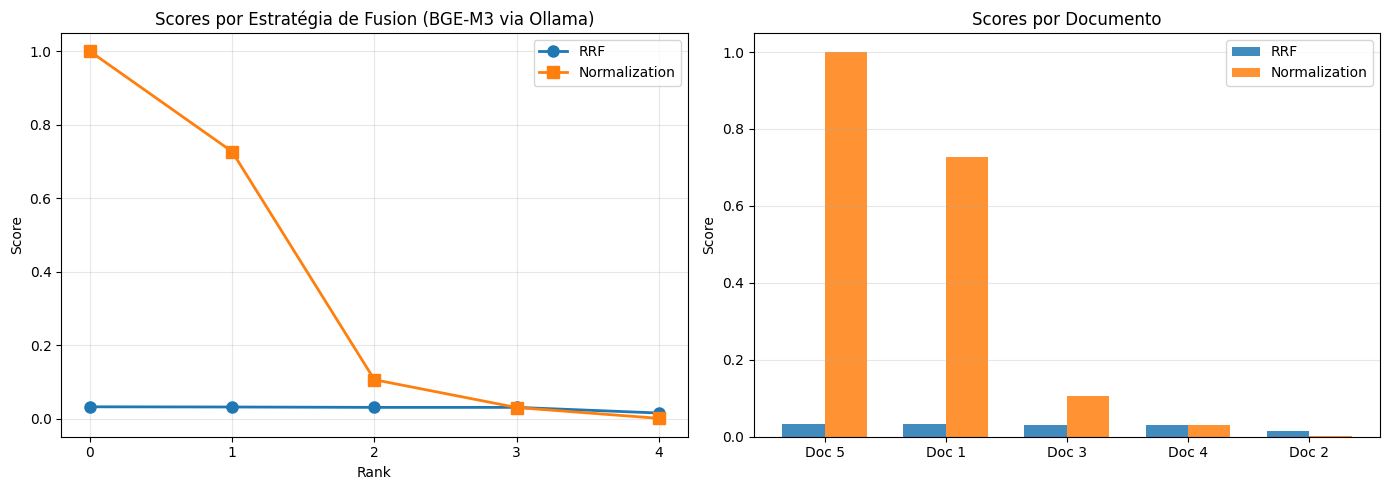

✓ Gráfico salvo: rrf_vs_normalization_bge_m3.png


In [12]:
if len(df_rrf) and len(df_norm):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Linha por rank
    ax = axes[0]
    x = range(len(df_rrf))
    ax.plot(x, df_rrf['score'].values,  marker='o', label='RRF',           linewidth=2, markersize=8)
    ax.plot(x, df_norm['score'].values, marker='s', label='Normalization', linewidth=2, markersize=8)
    ax.set_xlabel('Rank'); ax.set_ylabel('Score')
    ax.set_title('Scores por Estratégia de Fusion (BGE-M3 via Ollama)')
    ax.legend(); ax.grid(True, alpha=0.3); ax.set_xticks(list(x))

    # Barras por documento
    ax = axes[1]
    docs   = [f'Doc {i}' for i in df_rrf['id'].values]
    x      = range(len(docs)); w = 0.35
    ax.bar([i - w/2 for i in x], df_rrf['score'].values,  w, label='RRF',           alpha=0.85)
    ax.bar([i + w/2 for i in x], df_norm['score'].values, w, label='Normalization', alpha=0.85)
    ax.set_ylabel('Score'); ax.set_title('Scores por Documento')
    ax.set_xticks(list(x)); ax.set_xticklabels(docs)
    ax.legend(); ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig('rrf_vs_normalization_bge_m3.png', dpi=120, bbox_inches='tight')
    plt.show()
    print("✓ Gráfico salvo: rrf_vs_normalization_bge_m3.png")
else:
    print('Dados insuficientes para gráfico')

## Tabela de Decisão: Quando Usar Cada Técnica

In [13]:
decision_table = pd.DataFrame([
    {'Aspecto': 'Processor',                'RRF': 'score-ranker-processor',    'Normalization': 'normalization-processor'},
    {'Aspecto': 'Algoritmo',                'RRF': 'Reciprocal Rank Fusion',     'Normalization': 'Min-Max + arithmetic_mean'},
    {'Aspecto': 'Fórmula',                  'RRF': '1 / (k + rank)',             'Normalization': '(s - min) / (max - min)'},
    {'Aspecto': 'Parâmetro principal',      'RRF': 'rank_constant (default 60)', 'Normalization': 'weights por query'},
    {'Aspecto': 'Suporta weights',          'RRF': 'Não (roadmap)',              'Normalization': 'Sim'},
    {'Aspecto': 'Sensibilidade a outliers', 'RRF': 'Baixa (rank ordinal)',       'Normalization': 'Alta (depende de min/max)'},
    {'Aspecto': 'Escala dos scores',        'RRF': 'estreita (~1/60..1/61)',     'Normalization': '[0, 1] (exato)'},
    {'Aspecto': 'Estabilidade',             'RRF': 'Muito estável',              'Normalization': 'Menos com outliers'},
    {'Aspecto': 'Performance',              'RRF': '~1.6% mais rápido (blog)',   'Normalization': 'Levemente mais lento'},
    {'Aspecto': 'NDCG@10 (média blog)',     'RRF': '−3.86% vs hybrid clássico',  'Normalization': 'Baseline'},
    {'Aspecto': 'Recomendação',             'RRF': '✓ Padrão p/ alta vazão',     'Normalization': '⚠ Use p/ pesos custom'},
])
print('\n' + '='*100)
print('TABELA DE DECISÃO: RRF vs NORMALIZATION (com BGE-M3 via Ollama)')
print('='*100)
print(decision_table.to_string(index=False))
print('='*100)


TABELA DE DECISÃO: RRF vs NORMALIZATION (com BGE-M3 via Ollama)
                 Aspecto                        RRF             Normalization
               Processor     score-ranker-processor   normalization-processor
               Algoritmo     Reciprocal Rank Fusion Min-Max + arithmetic_mean
                 Fórmula             1 / (k + rank)   (s - min) / (max - min)
     Parâmetro principal rank_constant (default 60)         weights por query
         Suporta weights              Não (roadmap)                       Sim
Sensibilidade a outliers       Baixa (rank ordinal) Alta (depende de min/max)
       Escala dos scores     estreita (~1/60..1/61)            [0, 1] (exato)
            Estabilidade              Muito estável        Menos com outliers
             Performance   ~1.6% mais rápido (blog)      Levemente mais lento
    NDCG@10 (média blog)  −3.86% vs hybrid clássico                  Baseline
            Recomendação     ✓ Padrão p/ alta vazão     ⚠ Use p/ pesos custom

## Recomendações Práticas

In [14]:
recommendations = """
==============================================================================
 QUANDO USAR CADA TÉCNICA (com embeddings Ollama BGE-M3)
==============================================================================

 USE RRF (score-ranker-processor):
  ✓ Não conhece a distribuição dos scores
  ✓ Quer máxima estabilidade e robustez
  ✓ Busca informacional sem preferências claras
  ✓ Scores BM25 (TF-IDF) e kNN (cossenossimilaridade BGE-M3) têm escalas
    muito diferentes — RRF normaliza por rank, ignora a escala
  ✓ Alta vazão (RRF é ~1.6% mais rápido nos benchmarks oficiais)
  ✓ É o caso de ~90% das aplicações

 USE NORMALIZATION (normalization-processor, min-max):
  ⚠ Quer controlar pesos explicitamente (ex: 70% BM25 / 30% kNN)
  ⚠ Precisa de scores interpretáveis em [0,1]
  ⚠ Distribuição dos scores é estável e conhecida
  ⚠ Maior NDCG@10 em média (~3.86% acima de RRF nos benchmarks oficiais)

 AJUSTE DO rank_constant (RRF):
  - rank_constant grande (ex: 100): suaviza diferenças entre ranks
  - rank_constant pequeno (ex: 10): destaca top-ranked
  - default 60 (recomendado pelo paper original de Cormack et al.)
==============================================================================
"""
print(recommendations)


 QUANDO USAR CADA TÉCNICA (com embeddings Ollama BGE-M3)

 USE RRF (score-ranker-processor):
  ✓ Não conhece a distribuição dos scores
  ✓ Quer máxima estabilidade e robustez
  ✓ Busca informacional sem preferências claras
  ✓ Scores BM25 (TF-IDF) e kNN (cossenossimilaridade BGE-M3) têm escalas
    muito diferentes — RRF normaliza por rank, ignora a escala
  ✓ Alta vazão (RRF é ~1.6% mais rápido nos benchmarks oficiais)
  ✓ É o caso de ~90% das aplicações

 USE NORMALIZATION (normalization-processor, min-max):
  ⚠ Quer controlar pesos explicitamente (ex: 70% BM25 / 30% kNN)
  ⚠ Precisa de scores interpretáveis em [0,1]
  ⚠ Distribuição dos scores é estável e conhecida
  ⚠ Maior NDCG@10 em média (~3.86% acima de RRF nos benchmarks oficiais)

 AJUSTE DO rank_constant (RRF):
  - rank_constant grande (ex: 100): suaviza diferenças entre ranks
  - rank_constant pequeno (ex: 10): destaca top-ranked
  - default 60 (recomendado pelo paper original de Cormack et al.)



## Snippet Copiável (Ollama BGE-M3 + sintaxe oficial RRF)

In [ ]:
snippet = '''
import os, requests
from opensearchpy import OpenSearch

OLLAMA_BASE_URL    = os.getenv("OLLAMA_BASE_URL", "http://localhost:11434")
OLLAMA_EMBED_MODEL = os.getenv("OLLAMA_EMBED_MODEL", "bge-m3")

def ollama_embed(text):
    r = requests.post(f"{OLLAMA_BASE_URL}/api/embeddings",
                      json={"model": OLLAMA_EMBED_MODEL, "prompt": text}, timeout=60)
    return r.json()["embedding"]

# Pipeline RRF — sintaxe oficial OpenSearch 2.19+
# Ref.: https://opensearch.org/blog/introducing-reciprocal-rank-fusion-hybrid-search/
rrf_pipeline = {
    "description": "Post processor for hybrid RRF search",
    "phase_results_processors": [{
        "score-ranker-processor": {
            "combination": {
                "technique": "rrf",
                "rank_constant": 60   # default
            }
        }
    }]
}

# Pipeline Min-Max (pesos custom)
norm_pipeline = {
    "description": "Min-Max + arithmetic_mean",
    "phase_results_processors": [{
        "normalization-processor": {
            "normalization": {"technique": "min_max"},
            "combination":   {"technique": "arithmetic_mean",
                              "parameters": {"weights": [0.6, 0.4]}}
        }
    }]
}

# Hybrid query — vetor BGE-M3 vem do Ollama
q_emb = ollama_embed("sua query aqui")
body = {
    "size": 5,
    "query": {
        "hybrid": {
            "queries": [
                {"multi_match": {"query": "sua query aqui",
                                   "fields": ["titulo^2", "conteudo"]}},
                {"knn": {"embedding": {"vector": q_emb, "k": 5}}}
            ]
        }
    }
}
# client.search(index="...", body=body, params={"search_pipeline": "rrf-pipeline"})
'''
print(snippet)

## Resumo Executivo

In [ ]:
summary = """
==============================================================================
 RESUMO: RRF vs NORMALIZATION (embeddings BGE-M3 via Ollama, dim=1024)
==============================================================================

 Métrica              | RRF (score-ranker)   | NORMALIZATION (normalization)
 ---------------------+----------------------+-----------------------------
 Recomendação         | ★★★★★                | ★★★
 Complexidade         | Simples              | Média
 Estabilidade         | Muito alta           | Média
 Performance          | Excelente            | Boa
 Interpretabilidade   | Fácil                | Média
 Customização         | Baixa                | Alta
 Ideal para           | Maioria dos casos    | Casos com pesos específicos

 RECOMENDAÇÃO FINAL:
 - Comece com RRF (padrão seguro, sintaxe oficial OpenSearch 2.19+)
 - Migre para Normalization se tiver razão específica (ex: usuário quer
   priorizar BM25 explicitamente em domínio jurídico com terminologia técnica)
==============================================================================
"""
print(summary)

## Referências (ABNT)

BOGAN, R.; GAIEVSKI, M.; SHAH, M.; KOLCHINA, F. **Introducing reciprocal rank fusion for hybrid search**. OpenSearch Blog, 12 fev. 2025. Disponível em: <https://opensearch.org/blog/introducing-reciprocal-rank-fusion-hybrid-search/>.

CORMACK, G. V.; CLARKE, C. L. A.; BUETTCHER, S. **Reciprocal Rank Fusion Outperforms Condorcet and individual Rank Learning Methods**. SIGIR, 2009.

OPENSEARCH PROJECT. **Hybrid query / Search pipelines**. 3.0 Docs. <https://docs.opensearch.org/3.0/vector-search/ai-search/hybrid-search/>.

CHEN, J. et al. **BGE M3-Embedding**. arXiv:2309.07597, 2024.

OLLAMA. **BGE-M3 model card**. <https://ollama.com/library/bge-m3>.